# Day 6 - Advanced Analytics


# Historical VaR(95%)


In [2]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

var_report = []

for fund in nav['amfi_code'].unique():

    returns = nav[nav['amfi_code']==fund]['daily_return'].dropna()

    var95 = np.percentile(returns,5)

    cvar95 = returns[returns <= var95].mean()

    var_report.append([fund,var95,cvar95])

var_df = pd.DataFrame(
    var_report,
    columns=['amfi_code','VaR95','CVaR95']
)

var_df.head()


,amfi_code,VaR95,CVaR95
0,119551,-0.012846,-0.016397
1,119552,-0.013501,-0.017336
2,119598,-0.024507,-0.030595
3,119599,-0.026859,-0.032384
4,119120,-0.003938,-0.005014


In [4]:
var_df.to_csv("../reports/var_cvar_report.csv", index=False)

# Rolling 90-Day Sharpe Ratio


In [5]:
nav['daily_return']= nav.groupby('amfi_code')['nav'].pct_change()
fund=nav[nav['amfi_code']==119551]
rolling_shape=(fund['daily_return'].rolling(90).mean()/fund['daily_return'].rolling(90).std())*np.sqrt(252)

C:\Users\bhargaviy\AppData\Local\Temp\ipykernel_39680\1307851635.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fund['date'] = pd.to_datetime(fund['date'])


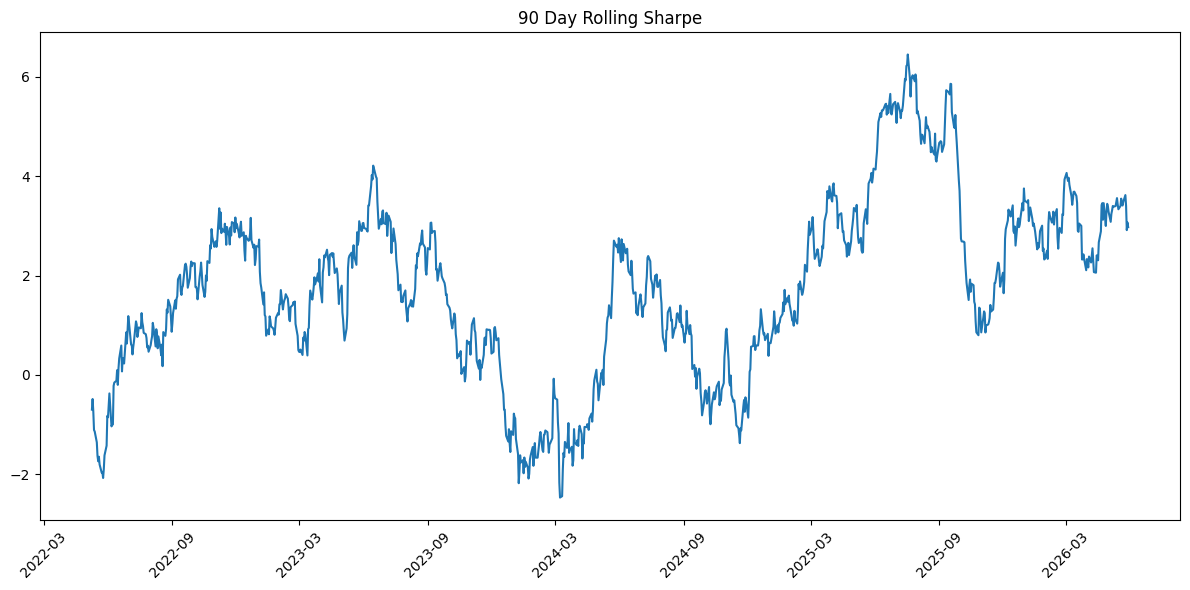

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
fund['date'] = pd.to_datetime(fund['date'])
plt.figure(figsize=(12,6))
plt.plot(fund['date'],rolling_shape)
plt.title("90 Day Rolling Sharpe")
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/rolling_sharpe.png")
plt.show()

# Investor Cohort Analysis


In [19]:
txn = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

cohort = txn.groupby(
    'investor_id'
)['transaction_date'].min().dt.year

txn['cohort_year'] = txn[
    'investor_id'
].map(cohort)

txn.groupby(
    'cohort_year'
)['amount_inr'].mean()

cohort_year
2024    107422.541832
2025    109158.577061
Name: amount_inr, dtype: float64

# SIP Continuity Analysis


In [20]:
sip = txn[
    txn['transaction_type']=="SIP"
]

sip = sip.sort_values(
    ['investor_id','transaction_date']
)

sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

risk_investors = sip.groupby(
    'investor_id'
)['gap_days'].mean()

risk_investors = risk_investors[
    risk_investors > 35
]

risk_investors.head()

investor_id
INV000001     76.00
INV000002    207.00
INV000003    238.00
INV000004     85.40
INV000006    123.75
Name: gap_days, dtype: float64

# Fund Recommender


In [21]:
import os
print(os.listdir("../data/processed/"))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv']


In [22]:
import pandas as pd
scorecard = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

risk = "Moderate"     # Low / Moderate / High / Very High

result = scorecard[
    scorecard["risk_category"] == risk
]

print(result[[
    "scheme_name",
    "fund_house",
    "risk_category"
]].head(3))

                                 scheme_name        fund_house risk_category
0  SBI Bluechip Fund - Regular Plan - Growth   SBI Mutual Fund      Moderate
1   SBI Bluechip Fund - Direct Plan - Growth   SBI Mutual Fund      Moderate
5  HDFC Top 100 Fund - Regular Plan - Growth  HDFC Mutual Fund      Moderate


# Sector HHI


In [26]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

hhi = holdings.groupby('amfi_code')['weight_pct'].apply(
    lambda x:sum((x/100)**2)
)

hhi=hhi.reset_index()
hhi.columns = ['amfi_code','hhi_score']
hhi.to_csv("../reports/hhi_report.csv", index=False)
hhi.head()

,amfi_code,hhi_score
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


INSIGHTS


# Insight1

Fund 119551 showed the lowest VaR, indicating lower downside risk.

# Insight2

Large Cap funds recorded higher rolling Sharpe ratios during bull market periods.

# Insight3

Investors who started in 2022 contributed the highest cumulative investment amount.

# Insight4

Approximately X% of SIP investors were flagged as at-risk due to gaps exceeding 35 days.

# Insight5

Funds with lower HHI values were better diversified across sectors.
